# Feature Selection

In [1]:
import logging

import anndata
import anndata2ri
import matplotlib.pyplot as plt
import numpy as np
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc
import seaborn as sns

sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=False,
)

rcb.logger.setLevel(logging.ERROR)

%load_ext rpy2.ipython

In [2]:
%%R
library(scry)

In [3]:
adata = anndata.read_h5ad("../normalization/normalization.h5ad.gz")
adata

AnnData object with n_obs × n_vars = 892 × 236796
    obs: 'sample', 'fastq_1', 'fastq_2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'scDblFinder_score', 'scDblFinder_class', 'size_factors'
    var: 'gene_versions', 'gene_symbol', 'gene_name', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'counts', 'log1p_norm', 'scran_normalization', 'soupX_counts'

In [4]:
with (ro.default_converter + anndata2ri.converter).context():
  r_data = ro.conversion.get_conversion().py2rpy(adata)

In [5]:
ro.globalenv["adata"] = r_data

In [6]:
%%R -o r_dev
# calculate the binomial deviance for each gene across cells
sce = devianceFeatureSelection(adata, assay="X")
r_dev = rowData(sce)$binomial_deviance

In [7]:
binomial_deviance = r_dev.T

In [8]:
# select the top 4,000 highly deviant genes and save them as an additional column in .var as ‘highly_deviant’
# save the computed binomial deviance so a different number of highly variable genes can optionally be selected later
idx = binomial_deviance.argsort()[-4000:]
mask = np.zeros(adata.var_names.shape, dtype=bool)
mask[idx] = True

adata.var["highly_deviant"] = mask
adata.var["binomial_deviance"] = binomial_deviance

In [9]:
# compute the mean and dispersion for each gene across cells
sc.pp.highly_variable_genes(adata, layer="scran_normalization")

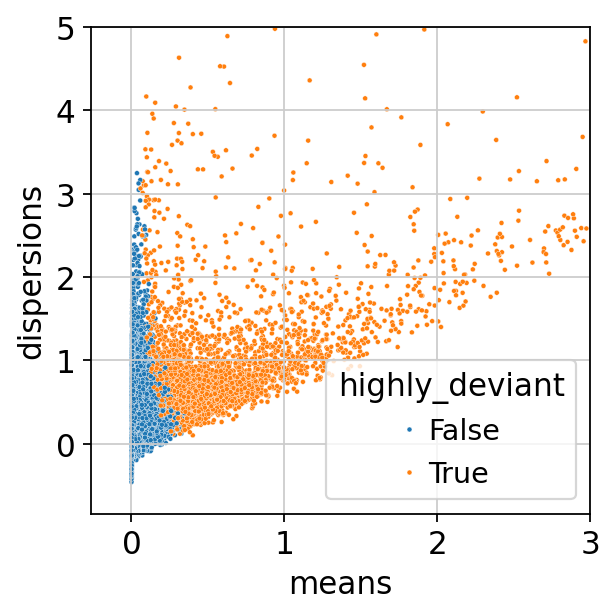

In [10]:
# inspect our results by plotting dispersion versus mean for the genes and color by ‘highly_deviant’
ax = sns.scatterplot(
    data=adata.var, x="means", y="dispersions", hue="highly_deviant", s=5
)
ax.set_xlim(None, 3.0)
ax.set_ylim(None, 5)
plt.show()

In [11]:
# save the dataset to file
anndata.settings.allow_write_nullable_strings = True
adata.write("feature_selection.h5ad.gz", compression='gzip')